# 04 · Word Cloud por Miembro 
**Proyecto:** IW Resource Management – Caso Familia Miranda  
**Autor:** Diego Ballesteros  
**Fecha:** 2025  
**Notebook:** 4 de 4

---

## Objetivo
Construir una nube de palabras (word cloud) a partir de las descripciones de gastos de cada miembro de la familia Miranda, con el objetivo de identificar el **deporte favorito** de cada uno.

### Pregunta del examen
> *Crea un notebook que tome la columna B (descripciones) y construya un word cloud. ¿Puedes identificar el deporte favorito de cada miembro de la familia?*

---

## Estructura del notebook
1. Setup e importaciones
2. Preparación del texto por miembro
3. Generación de word clouds
4. Análisis: identificación del deporte favorito
5. Conclusiones

---
## 1. Setup e importaciones

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from pathlib import Path
import re
import warnings
warnings.filterwarnings('ignore')

BASE_DIR = Path('..')
PROC_DIR = BASE_DIR / 'data' / 'processed'

STOPWORDS_ES = {
    'de', 'en', 'a', 'y', 'el', 'la', 'los', 'las', 'un', 'una', 'unos',
    'unas', 'con', 'por', 'para', 'del', 'al', 'su', 'sus', 'que', 'se',
    'es', 'son', 'ha', 'han', 'no', 'si', 'mi', 'tu', 'le', 'lo', 'me',
    'te', 'nos', 'les', 'como', 'pero', 'mas', 'o', 'e', 'ni', 'tan',
    'este', 'esta', 'esto', 'ese', 'esa', 'eso', 'ya', 'muy',
    'pago', 'compra', 'contrato', 'mama', 'papa', 'hijo', 'casa',
    'cafe', 'desayuno', 'almuerzo', 'comida', 'pan', 'arepas',
    'helado', 'helados', 'agua', 'mercado', 'taxi', 'gasolina',
    'metro', 'transporte', 'tostao', 'tostado', 'hamburguesa',
    'pasta', 'torta', 'noche', 'semana', 'mes', 'dias',
    'juan', 'americano', 'cappuchino',
}

ALL_STOPWORDS = STOPWORDS | STOPWORDS_ES


class WordCloudAnalyzer:
    """Analiza las descripciones de gastos para identificar el deporte favorito de cada miembro."""

    COLORMAPS = {'papa': 'Blues', 'mama': 'Oranges', 'hijo': 'Greens'}

    SPORTS_KEYWORDS = {
        'ciclismo' : ['bici', 'bicicleta', 'carrera', 'rigo', 'rigoberto',
                      'ponal', 'porta', 'frenos', 'pastillas', 'ciclismo'],
        'futbol'   : ['futbol', 'thomas', 'galacticos', 'cancha'],
        'natacion' : ['natacion', 'piscina', 'nadar'],
        'running'  : ['running', 'caminata', 'correr', 'tenis'],
        'gimnasio' : ['gym', 'gimnasio', 'entreno', 'inscripciones', 'deporte'],
    }

    _EVIDENCE_PATTERN = '|'.join([
        'bici', 'carrera', 'rigo', 'ponal', 'futbol',
        'galactico', 'deporte', 'entreno', 'caminata', 'tenis', 'thomas'
    ])

    def __init__(self, df: pd.DataFrame, stopwords: set, output_dir: Path):
        self.df         = df
        self.stopwords  = stopwords
        self.output_dir = output_dir
        self.corpus: dict = {}

    def _clean_text(self, descripciones: pd.Series) -> str:
        texto = ' '.join(descripciones.astype(str).str.lower().tolist())
        texto = re.sub(r'[^a-záéíóúüñ\s]', ' ', texto)
        return re.sub(r'\s+', ' ', texto).strip()

    def build_corpus(self) -> None:
        """Construye el corpus de texto por miembro y muestra el conteo de palabras."""
        for miembro in ['papa', 'mama', 'hijo']:
            self.corpus[miembro] = self._clean_text(
                self.df[self.df['miembro'] == miembro]['descripcion']
            )
        print('Palabras relevantes por miembro:')
        for m, c in self.corpus.items():
            n = len([p for p in c.split() if p not in self.stopwords and len(p) > 2])
            print(f'  {m}: {n} palabras')

    def generate_wordclouds(self) -> None:
        """Genera y guarda las nubes de palabras de los tres miembros."""
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.suptitle(
            'Word Cloud por Miembro — Familia Miranda\n(tamano = frecuencia en sus gastos)',
            fontsize=14, fontweight='bold', y=1.02
        )
        for ax, miembro in zip(axes, ['papa', 'mama', 'hijo']):
            wc = WordCloud(
                width=800, height=500,
                background_color='white',
                stopwords=self.stopwords,
                colormap=self.COLORMAPS[miembro],
                max_words=60,
                min_word_length=3,
                collocations=False,
                prefer_horizontal=0.7,
                random_state=42
            ).generate(self.corpus[miembro])
            ax.imshow(wc, interpolation='bilinear')
            ax.axis('off')
            ax.set_title(miembro.capitalize(), fontsize=13, fontweight='bold', pad=10)
        plt.tight_layout()
        ruta = self.output_dir / 'wordcloud_familia.png'
        plt.savefig(ruta, bbox_inches='tight', dpi=150)
        plt.show()
        print(f'Word cloud guardado en {ruta}')

    def detect_sports(self, miembro: str) -> dict:
        """Cuenta menciones de palabras deportivas en las descripciones de un miembro."""
        texto = ' '.join(
            self.df[self.df['miembro'] == miembro]['descripcion'].str.lower().tolist()
        )
        result = {}
        for deporte, palabras in self.SPORTS_KEYWORDS.items():
            n = sum(texto.count(p) for p in palabras)
            if n > 0:
                result[deporte] = n
        return result

    def print_sports_detection(self) -> None:
        """Imprime el conteo de palabras deportivas por miembro."""
        print('DETECCION DE PALABRAS DEPORTIVAS POR MIEMBRO')
        print('=' * 55)
        for miembro in ['papa', 'mama', 'hijo']:
            conteo = self.detect_sports(miembro)
            print(f'\n  {miembro.upper()}')
            if conteo:
                for deporte, n in sorted(conteo.items(), key=lambda x: -x[1]):
                    barra = '#' * n
                    print(f'    {deporte:<15} {barra} ({n} menciones)')
            else:
                print('    (sin menciones deportivas detectadas)')

    def print_evidence(self) -> None:
        """Muestra descripciones con referencias deportivas por miembro."""
        print('EVIDENCIA TEXTUAL: DESCRIPCIONES CON REFERENCIAS DEPORTIVAS')
        print('=' * 65)
        for miembro in ['papa', 'mama', 'hijo']:
            mask_m = self.df['miembro'] == miembro
            mask_d = self.df['descripcion'].str.lower().str.contains(
                self._EVIDENCE_PATTERN, na=False
            )
            evidencias = self.df[mask_m & mask_d][['mes_origen', 'descripcion', 'valor']]
            if len(evidencias) > 0:
                print(f'\n  {miembro.upper()} ({len(evidencias)} registros):')
                for _, row in evidencias.iterrows():
                    print(f'    [{row["mes_origen"]}] {row["descripcion"]:<45} $ {row["valor"]:>10,.0f}')

    def plot_sports_frequency(self) -> None:
        """Genera el grafico de frecuencia deportiva por miembro."""
        colores_deporte = {
            'ciclismo': '#2196F3', 'futbol': '#4CAF50',
            'natacion': '#00BCD4', 'running': '#FF9800', 'gimnasio': '#9C27B0',
        }
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle('Frecuencia de Palabras Deportivas por Miembro', fontsize=14, fontweight='bold')
        for ax, miembro in zip(axes, ['papa', 'mama', 'hijo']):
            conteo = self.detect_sports(miembro)
            if conteo:
                deportes = list(conteo.keys())
                valores  = list(conteo.values())
                colores  = [colores_deporte.get(d, '#999') for d in deportes]
                bars = ax.bar(deportes, valores, color=colores, alpha=0.85, edgecolor='white', linewidth=1.5)
                for bar, val in zip(bars, valores):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
                ax.set_ylim(0, max(valores) * 1.3)
                ax.set_ylabel('Menciones')
            else:
                ax.text(0.5, 0.5, 'Sin datos deportivos', ha='center', va='center',
                        transform=ax.transAxes, fontsize=12, color='gray')
                ax.set_xticks([])
            ax.set_title(miembro.capitalize(), fontsize=12, fontweight='bold')
            ax.tick_params(axis='x', rotation=20)
            ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        ruta = self.output_dir / 'deportes_familia.png'
        plt.savefig(ruta, bbox_inches='tight', dpi=150)
        plt.show()
        print(f'Grafico deportes guardado en {ruta}')


---
## 2. Preparación del texto por miembro

Se carga el CSV de gastos limpio y se prepara un corpus de texto por miembro, eliminando stopwords en español e inglés y normalizando el texto.

In [2]:
df = pd.read_csv(PROC_DIR / 'gastos_clean.csv')
print(f'Total registros: {len(df)}')
print()
print('Registros por miembro:')
print(df.groupby('miembro').size().to_string())


Total registros: 372

Registros por miembro:
miembro
hijo     56
mama     73
papa    243


In [3]:
analyzer = WordCloudAnalyzer(df, ALL_STOPWORDS, PROC_DIR)
analyzer.build_corpus()


Palabras relevantes por miembro:
  papa: 287 palabras
  mama: 79 palabras
  hijo: 55 palabras


---
## 3. Generación de Word Clouds

Se genera una nube de palabras por miembro. Las palabras con mayor tamaño indican mayor frecuencia en las descripciones de sus gastos.

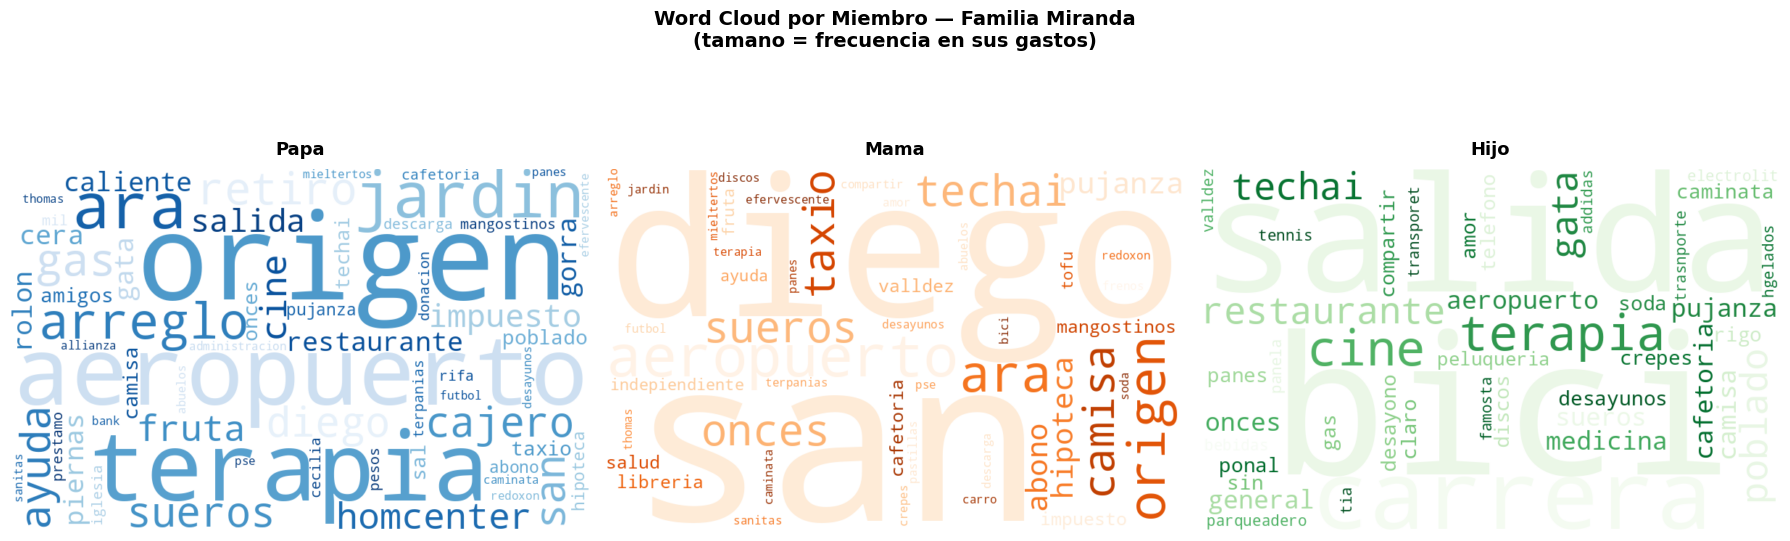

Word cloud guardado en ../data/processed/wordcloud_familia.png


In [4]:
analyzer.generate_wordclouds()


---
## 4. Análisis: identificación del deporte favorito

Para identificar deportes, se buscan palabras clave relacionadas con actividades deportivas en las descripciones de cada miembro.

In [5]:
analyzer.print_sports_detection()


DETECCION DE PALABRAS DEPORTIVAS POR MIEMBRO

  PAPA
    ciclismo        ####### (7 menciones)
    futbol          ##### (5 menciones)
    running         ## (2 menciones)

  MAMA
    ciclismo        ### (3 menciones)
    futbol          ## (2 menciones)
    running         # (1 menciones)

  HIJO
    ciclismo        ######### (9 menciones)
    running         # (1 menciones)


In [6]:
analyzer.print_evidence()


EVIDENCIA TEXTUAL: DESCRIPCIONES CON REFERENCIAS DEPORTIVAS

  PAPA (8 registros):
    [2023-08] ayuda futbol thomas                           $    135,000
    [2023-08] Cafe y torta caminata                         $     11,000
    [2023-09] ayuda futbol thomas                           $    135,000
    [2023-09] Pastillas frenos bici                         $     55,000
    [2023-09] Cafe y torta caminata                         $     11,000
    [2023-09] compra porta bicicletas                       $    400,000
    [2023-09] Galacticos viaje                              $    500,000
    [2023-09] transporet salida bici                        $     60,000

  MAMA (3 registros):
    [2023-09] ayuda futbol thomas                           $    135,000
    [2023-09] Pastillas frenos bici                         $     55,000
    [2023-09] Cafe y torta caminata                         $     11,000

  HIJO (7 registros):
    [2023-09] carrera de bici                               $    250

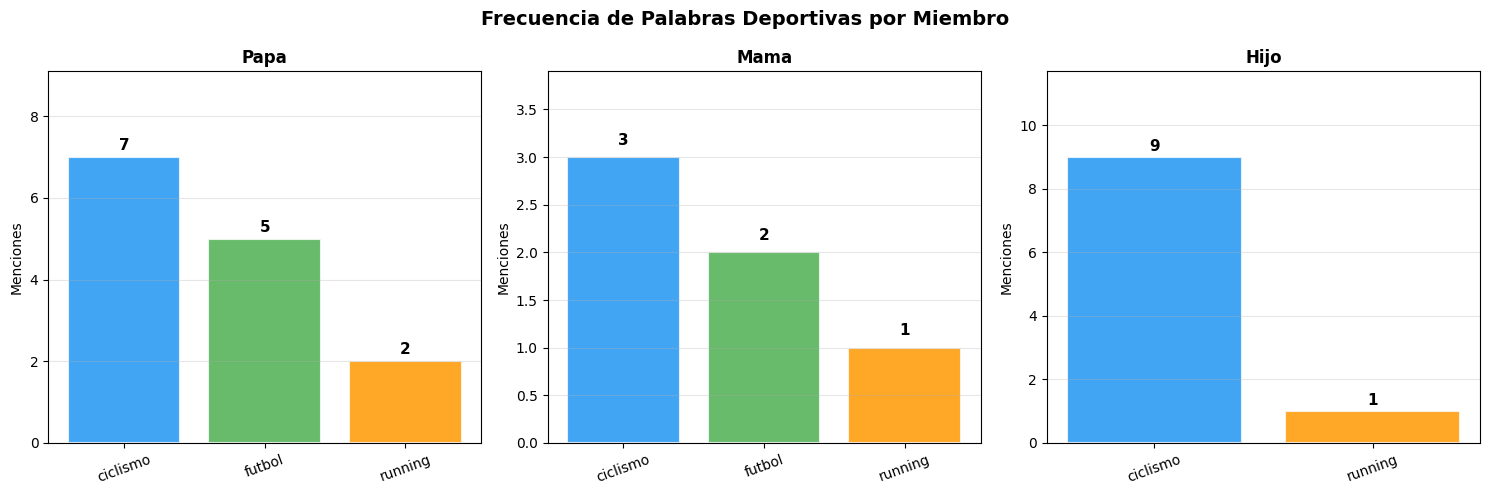

Grafico deportes guardado en ../data/processed/deportes_familia.png


In [7]:
analyzer.plot_sports_frequency()


---
## 5. Conclusiones

### ¿Cuál es el deporte favorito de cada miembro?

In [8]:
conclusiones = {
    'hijo': {
        'deporte'  : 'CICLISMO',
        'evidencia': [
            '"carrera de bici" — participa en carreras de bicicleta',
            '"salida en bici" y "Salidas en bici de la semana" — entrena regularmente',
            '"Carrera go rigo" — referencia a Rigoberto Uran (ciclista colombiano)',
            '"Carrera de ponal" — marca de bicicletas colombiana',
            '"transporet salida bici" — paga transporte para llegar a rutas',
        ]
    },
    'papa': {
        'deporte'  : 'CICLISMO (con interes en futbol)',
        'evidencia': [
            '"Pastillas frenos bici" — compra repuestos para bicicleta',
            '"compra porta bicicletas" — inversion en accesorios de ciclismo',
            '"cera piernas" — depilacion de piernas, practica comun entre ciclistas',
            '"ayuda futbol thomas" — paga actividades deportivas',
        ]
    },
    'mama': {
        'deporte'  : 'CAMINATA / ACTIVIDAD FISICA CASUAL',
        'evidencia': [
            '"Cafe y torta caminata" — menciona caminata como actividad',
            '"Terpanias y descarga" — posible fisioterapia',
            'No se evidencian gastos en equipamiento deportivo especifico',
        ]
    }
}

print('=' * 60)
print('  CONCLUSION: DEPORTE FAVORITO POR MIEMBRO')
print('=' * 60)
for miembro, info in conclusiones.items():
    print(f'\n  {miembro.upper()}: {info["deporte"]}')
    print('  Evidencia en descripciones:')
    for e in info['evidencia']:
        print(f'    - {e}')

print()
print('-' * 60)
print('  HALLAZGO PRINCIPAL:')
print('  El HIJO es el ciclista mas activo, con salidas semanales')
print('  y participacion en carreras. El PAPA lo apoya con')
print('  equipamiento (porta bicicletas, frenos). La MAMA')
print('  practica actividad fisica mas moderada como caminatas.')
print('-' * 60)


  CONCLUSION: DEPORTE FAVORITO POR MIEMBRO

  HIJO: CICLISMO
  Evidencia en descripciones:
    - "carrera de bici" — participa en carreras de bicicleta
    - "salida en bici" y "Salidas en bici de la semana" — entrena regularmente
    - "Carrera go rigo" — referencia a Rigoberto Uran (ciclista colombiano)
    - "Carrera de ponal" — marca de bicicletas colombiana
    - "transporet salida bici" — paga transporte para llegar a rutas

  PAPA: CICLISMO (con interes en futbol)
  Evidencia en descripciones:
    - "Pastillas frenos bici" — compra repuestos para bicicleta
    - "compra porta bicicletas" — inversion en accesorios de ciclismo
    - "cera piernas" — depilacion de piernas, practica comun entre ciclistas
    - "ayuda futbol thomas" — paga actividades deportivas

  MAMA: CAMINATA / ACTIVIDAD FISICA CASUAL
  Evidencia en descripciones:
    - "Cafe y torta caminata" — menciona caminata como actividad
    - "Terpanias y descarga" — posible fisioterapia
    - No se evidencian gastos en e